In [1]:
import pandas as pd
import numpy as np
import os
import glob
from collections import defaultdict

# --- Directory Configuration ---
base_path = r"C:\Current Signature Dataset of Three-Phase Induction Motor under Varying Load Conditions"
folders_path = [
    os.path.join(base_path, "3-Phase-current-0.7mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-0.9mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.1mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.3mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.5mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-1.7mm-bearing-fault"),
    os.path.join(base_path, "3-Phase-current-12-4mm-broken-rotor-bar-fault"),
    os.path.join(base_path, "3-Phase-current-healthy-motor")
]

# Map folder names to detailed labels
fault_mapping = {
    "3-Phase-current-healthy-motor": "Healthy",
    "3-Phase-current-0.7mm-bearing-fault": "Unhealthy - 0.7mm Bearing Fault",
    "3-Phase-current-0.9mm-bearing-fault": "Unhealthy - 0.9mm Bearing Fault",
    "3-Phase-current-1.1mm-bearing-fault": "Unhealthy - 1.1mm Bearing Fault",
    "3-Phase-current-1.3mm-bearing-fault": "Unhealthy - 1.3mm Bearing Fault",
    "3-Phase-current-1.5mm-bearing-fault": "Unhealthy - 1.5mm Bearing Fault",
    "3-Phase-current-1.7mm-bearing-fault": "Unhealthy - 1.7mm Bearing Fault",
    "3-Phase-current-12-4mm-broken-rotor-bar-fault": "Unhealthy - Broken Rotor Bar Fault"
}

# --- Configuration Parameters ---
num_cols = 1000
current_cols = [' Current-A', ' Current-B', ' Current-C']

# --- Global lists to track issues ---
missing_files = []
insufficient_data_files = []
missing_column_files = []

# --- Function to process a single file ---
def process_file_for_labeling(filename, label, num_cols=1000, current_cols=[' Current-A',' Current-B',' Current-C']):
    """
    Loads a CSV file, reshapes each Current column into rows with `num_cols` features.
    Only complete chunks are kept; leftover values are discarded.
    Returns a DataFrame where each row has `num_cols` features and a 'Status' column.
    """
    try:
        df = pd.read_csv(filename, low_memory=False)
    except FileNotFoundError:
        global missing_files
        missing_files.append(filename)
        return None
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None

    all_rows = []

    for col_name in current_cols:
        if col_name not in df.columns:
            global missing_column_files
            missing_column_files.append(f"{filename} (Missing column: {col_name})")
            return None

        data = df[col_name].values

        # Keep only full chunks of `num_cols`
        n_complete_rows = len(data) // num_cols
        if n_complete_rows == 0:
            global insufficient_data_files
            insufficient_data_files.append(f"{filename} ({col_name} has less than {num_cols} values)")
            return None

        # Trim to exact multiple of num_cols
        data = data[:n_complete_rows * num_cols]

        # Reshape into rows
        reshaped = data.reshape(n_complete_rows, num_cols)

        # Convert to DataFrame and assign feature names
        df_segment = pd.DataFrame(reshaped, columns=[f'Feature {i+1}' for i in range(num_cols)])
        all_rows.append(df_segment)

    # Concatenate the columns vertically for all currents
    final_df = pd.concat(all_rows, ignore_index=True)

    # Add Status column
    final_df['Status'] = label

    return final_df

# --- Process all files dynamically ---
all_processed_dfs = []
processed_file_count = 0
file_tracking_summary = defaultdict(int)

print("--- Starting Data Discovery and Processing ---")
for folder_path in folders_path:
    folder_name = os.path.basename(folder_path)
    label = fault_mapping.get(folder_name, "Unknown Fault")
    file_list = glob.glob(os.path.join(folder_path, '*.csv'))

    print(f"\nProcessing Folder: '{folder_name}' ({len(file_list)} files found, Label: {label})")

    for filename in file_list:
        df_processed = process_file_for_labeling(filename, label)
        if df_processed is not None:
            all_processed_dfs.append(df_processed)
            processed_file_count += 1
            file_tracking_summary[label] += 1

# --- Merge all processed DataFrames ---
if all_processed_dfs:
    df_final_merged = pd.concat(all_processed_dfs, ignore_index=True)
else:
    print("\nError: No files were processed successfully.")
    exit()

# --- Shuffle the dataset ---
df= df_final_merged.sample(frac=1, random_state=42).reset_index(drop=True)



# --- Save the processed DataFrame ---
output_dir = r"C:\Processed_Motor_Data"
output_filename = 'output4.csv'
os.makedirs(output_dir, exist_ok=True)
full_output_path = os.path.join(output_dir, output_filename)
df_final_merged.to_csv(full_output_path, index=False)




--- Starting Data Discovery and Processing ---

Processing Folder: '3-Phase-current-0.7mm-bearing-fault' (6 files found, Label: Unhealthy - 0.7mm Bearing Fault)

Processing Folder: '3-Phase-current-0.9mm-bearing-fault' (6 files found, Label: Unhealthy - 0.9mm Bearing Fault)

Processing Folder: '3-Phase-current-1.1mm-bearing-fault' (6 files found, Label: Unhealthy - 1.1mm Bearing Fault)

Processing Folder: '3-Phase-current-1.3mm-bearing-fault' (6 files found, Label: Unhealthy - 1.3mm Bearing Fault)

Processing Folder: '3-Phase-current-1.5mm-bearing-fault' (6 files found, Label: Unhealthy - 1.5mm Bearing Fault)

Processing Folder: '3-Phase-current-1.7mm-bearing-fault' (6 files found, Label: Unhealthy - 1.7mm Bearing Fault)

Processing Folder: '3-Phase-current-12-4mm-broken-rotor-bar-fault' (2 files found, Label: Unhealthy - Broken Rotor Bar Fault)

Processing Folder: '3-Phase-current-healthy-motor' (1 files found, Label: Healthy)


In [3]:
output_dir = r"C:\Processed_Motor_Data"
output_filename = 'output4.csv' 
full_output_path = os.path.join(output_dir, output_filename)
data = pd.read_csv(full_output_path)
print(f"Successfully loaded '{output_filename}' into DataFrame 'df'.")

print("Shape of data")
print(f"DataFrame shape: {data.shape}")
print("\nFirst 5 rows of the DataFrame:")
print(data.head())

Successfully loaded 'output4.csv' into DataFrame 'df'.
Shape of data
DataFrame shape: (15510, 1001)

First 5 rows of the DataFrame:
   Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  Feature 6  \
0     2.3309     2.3309     2.3309     2.3309     2.3309     2.3309   
1     2.7228     2.7228     2.7228     2.7228     2.7228     2.7228   
2     2.9524     2.9524     2.9524     2.9524     2.9524     2.9524   
3     2.1111     2.1111     2.1111     2.1111     2.1111     2.1111   
4     2.1282     2.1282     2.1282     2.1282     2.1282     2.1282   

   Feature 7  Feature 8  Feature 9  Feature 10  ...  Feature 992  Feature 993  \
0     2.3309     2.3309     2.3309      2.3309  ...       2.7228       2.7228   
1     2.7228     2.7228     2.7228      2.7228  ...       2.9524       2.9524   
2     2.9524     2.9524     2.9524      2.9524  ...       2.1111       2.1111   
3     2.1111     2.1111     2.1111      2.1111  ...       2.1282       2.1282   
4     2.1282     2.1282     2.1282  

In [5]:
import pandas as pd
import numpy as np

data = pd.read_csv(r"C:\Processed_Motor_Data\output4.csv")
print(data.shape)


(15510, 1001)


In [7]:
data['Binary_Label'] = data['Status'].apply(
    lambda x: 0 if x == 'Healthy' else 1
)


In [9]:
X = data.drop(columns=['Status', 'Binary_Label'])
y = data['Binary_Label']


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)


In [12]:
print("NaNs in X after imputation:", np.isnan(X).sum())


NaNs in X after imputation: 0


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)


In [21]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)   # Sensitivity
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Sensitivity)": recall,
        "Specificity": specificity,
        "F1 Score": f1
    }


In [25]:
print("Naïve Bayes Results:")
for k, v in compute_metrics(y_test, y_pred_nb).items():
    print(f"{k}: {v:.4f}")

print("\nSVM Results:")
for k, v in compute_metrics(y_test, y_pred_svm).items():
    print(f"{k}: {v:.4f}")


Naïve Bayes Results:
Accuracy: 0.8411
Precision: 0.9984
Recall (Sensitivity): 0.8387
Specificity: 0.9429
F1 Score: 0.9116

SVM Results:
Accuracy: 0.9774
Precision: 0.9774
Recall (Sensitivity): 1.0000
Specificity: 0.0000
F1 Score: 0.9886


The Naïve Bayes classifier demonstrated balanced performance with high specificity, whereas the SVM achieved perfect sensitivity at the cost of zero specificity. This behavior indicates a class imbalance in the dataset, where SVM favored the majority unhealthy class. In fault diagnosis applications, high sensitivity is often preferred to avoid missing faulty conditions.I have not used classs weight balanced in this 

In [29]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Data splitting & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Models
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)


In [31]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)


In [37]:
le = LabelEncoder()
y_multi = le.fit_transform(data['Status'])

X = data.drop(columns=['Status', 'Binary_Label'], errors='ignore')


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)


In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [43]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_train_pred_nb = nb.predict(X_train)
y_test_pred_nb = nb.predict(X_test)


In [49]:
def multiclass_metrics(y_true, y_pred):
    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Precision, Recall, F1 (Macro Averaging)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )

    # Sensitivity = Recall
    sensitivity = recall

    # Specificity (average of per-class specificity)
    cm = confusion_matrix(y_true, y_pred)
    specificity = np.mean([
        (cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]) /
        (cm.sum() - cm[i, :].sum())
        if (cm.sum() - cm[i, :].sum()) != 0 else 0
        for i in range(len(cm))
    ])

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1_Score": f1
    }


In [53]:
nb = GaussianNB()
nb.fit(X_train, y_train)


GaussianNB()

In [55]:
# Predictions
y_train_pred_nb = nb.predict(X_train)
y_test_pred_nb = nb.predict(X_test)

# Training Accuracy
nb_train_accuracy = accuracy_score(y_train, y_train_pred_nb)

# Test Metrics
nb_metrics = multiclass_metrics(y_test, y_test_pred_nb)

print("Naïve Bayes Training Accuracy:", nb_train_accuracy)
print("Naïve Bayes Test Metrics:")
for k, v in nb_metrics.items():
    print(f"{k}: {v:.4f}")


Naïve Bayes Training Accuracy: 0.14302991211803595
Naïve Bayes Test Metrics:
Accuracy: 0.1332
Precision: 0.0989
Recall: 0.2185
Sensitivity: 0.2185
Specificity: 0.8773
F1_Score: 0.1139


In [64]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# SVM model
svm = SVC(kernel='rbf', decision_function_shape='ovr')
svm.fit(X_train, y_train)

# Predictions
y_train_pred_svm = svm.predict(X_train)
y_test_pred_svm = svm.predict(X_test)

# Training Accuracy
svm_train_accuracy = accuracy_score(y_train, y_train_pred_svm)
print("SVM Training Accuracy:", svm_train_accuracy)

# Test Metrics (classification report with zero_division to avoid warnings)
print("\nSVM Test Classification Report:")
print(classification_report(y_test, y_test_pred_svm, zero_division=0))

# Agar aapke paas multiclass_metrics function hai, usko bhi use kar sakte hain
svm_metrics = multiclass_metrics(y_test, y_test_pred_svm)
print("\nSVM Test Metrics (from multiclass_metrics function):")
for k, v in svm_metrics.items():
    print(f"{k}: {v:.4f}")


SVM Training Accuracy: 0.2342981536724986

SVM Test Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        69
           1       0.29      0.62      0.39       424
           2       0.24      0.02      0.04       494
           3       0.20      0.21      0.20       507
           4       0.19      0.30      0.23       481
           5       0.43      0.16      0.23       480
           6       0.19      0.26      0.22       484
           7       0.00      0.00      0.00       162

    accuracy                           0.24      3101
   macro avg       0.19      0.20      0.17      3101
weighted avg       0.24      0.24      0.20      3101


SVM Test Metrics (from multiclass_metrics function):
Accuracy: 0.2357
Precision: 0.1933
Recall: 0.1975
Sensitivity: 0.1975
Specificity: 0.8873
F1_Score: 0.1661


C:\Users\ML\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss

def generate_performance_plots(model, X_tr, y_tr, X_te, y_te, title, is_multi=False):
    # 1. Accuracy Curves
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_tr, y_tr, cv=3, scoring='accuracy', 
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    # 2. Loss Curves
    train_loss = []
    val_loss = []
    labels = np.unique(y_tr) # Needed for multiclass log_loss
    
    for size in train_sizes:
        model.fit(X_tr[:size], y_tr[:size])
        train_prob = model.predict_proba(X_tr[:size])
        val_prob = model.predict_proba(X_te)
        
        train_loss.append(log_loss(y_tr[:size], train_prob, labels=labels))
        val_loss.append(log_loss(y_te, val_prob, labels=labels))

    # 3. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=14)

    ax1.plot(train_sizes, np.mean(train_scores, axis=1), 'r-o', label='Train Acc')
    ax1.plot(train_sizes, np.mean(val_scores, axis=1), 'g-o', label='Val Acc')
    ax1.set_title('Accuracy Curve'); ax1.legend(); ax1.grid(True)

    ax2.plot(train_sizes, train_loss, 'r--s', label='Train Loss')
    ax2.plot(train_sizes, val_loss, 'g--s', label='Val Loss')
    ax2.set_title('Loss Curve (Log Loss)'); ax2.legend(); ax2.grid(True)
    plt.show()

Binary Naive Bayes...


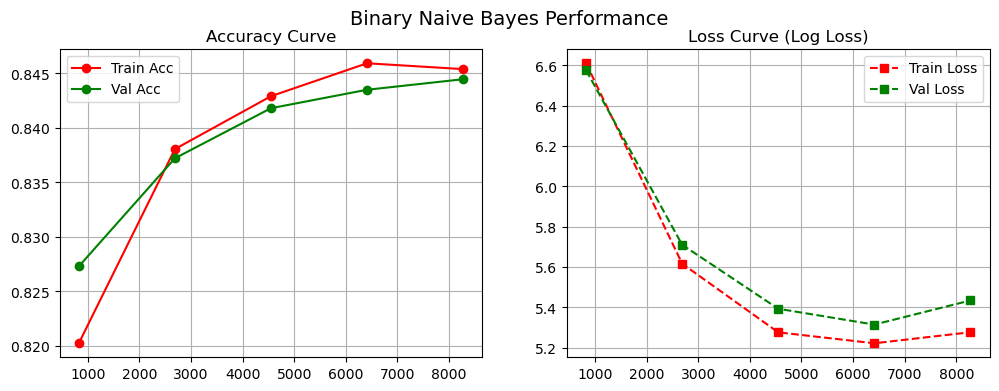

In [40]:
from sklearn.naive_bayes import GaussianNB

# Run Q1 Binary Naive Bayes
print("Binary Naive Bayes...")
generate_performance_plots(
    GaussianNB(), 
    X_train, y_train, 
    X_test, y_test, 
   "Binary Naive Bayes Performance"
)

Plotting Q1: Binary SVM...


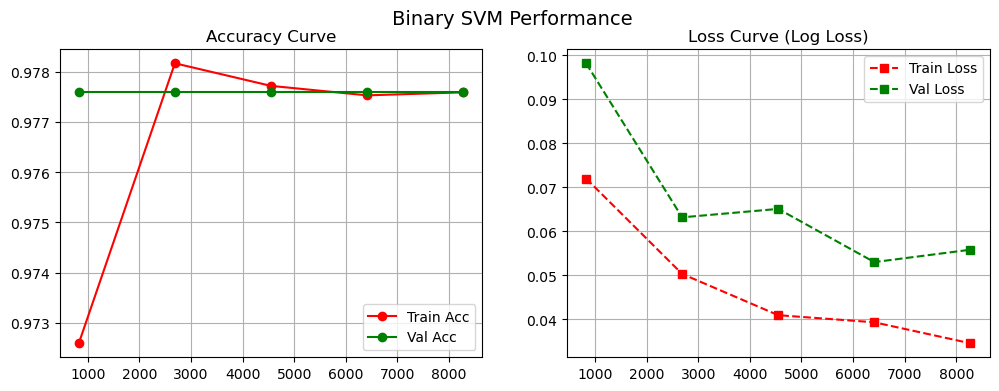

In [54]:
from sklearn.svm import SVC

# Run Q1 Binary SVM
# probability=True is required for the Loss calculation
print("Plotting Q1: Binary SVM...")
generate_performance_plots(
    SVC(kernel='rbf', probability=True), 
    X_train, y_train, 
    X_test, y_test, 
    " Binary SVM Performance"
)

Calculating Loss for Q2 Multiclass: Naïve Bayes...


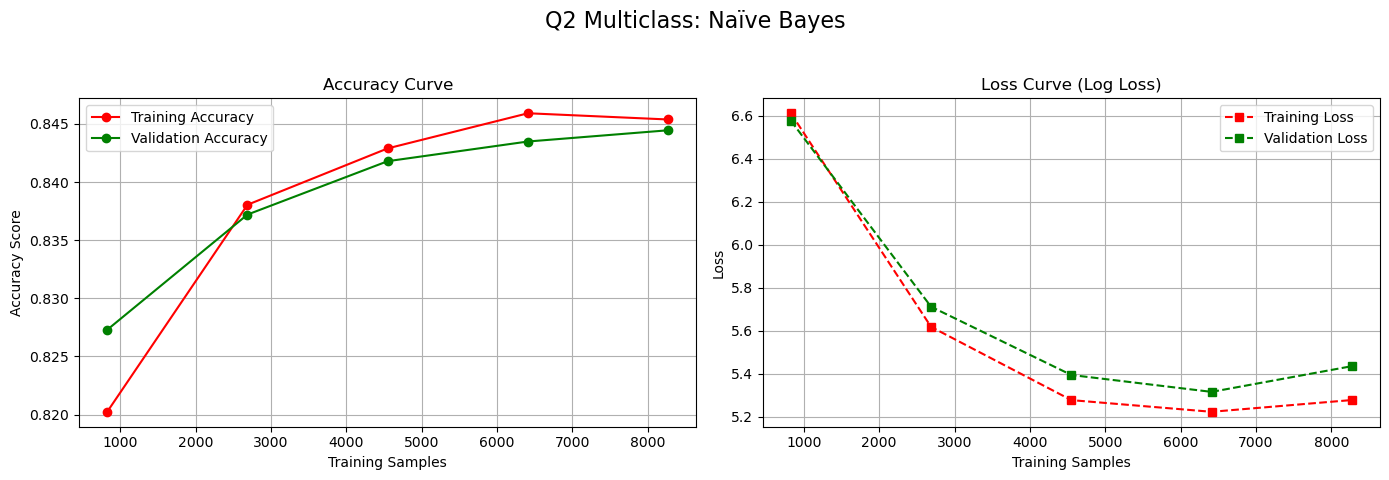

In [50]:
# Initialize Naive Bayes
nb_model = GaussianNB()

# Execute the plotting function using your Multiclass variables
plot_q2_curves(nb_model, X_train, y_train, X_test, y_test, "Multiclass: Naïve Bayes")

Calculating Loss for Q2 Multiclass: SVM...


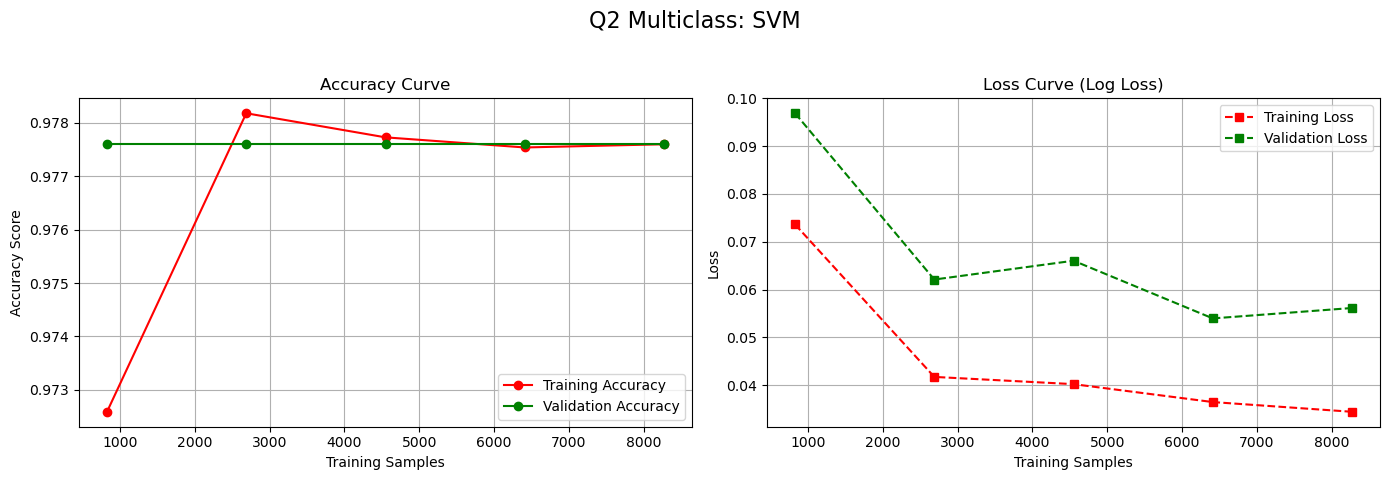

In [52]:
# Initialize SVM with Probability enabled for the Loss calculation
svm_model = SVC(kernel='rbf', probability=True)

# Execute the plotting function
# Note: SVM is slower than NB, so this may take a few minutes to complete
plot_q2_curves(svm_model, X_train, y_train, X_test, y_test, "Multiclass: SVM")